# Insect Image Generation using DCGAN

This notebook implements a Deep Convolutional Generative Adversarial Network (DCGAN) to generate realistic insect images.

## Overview

**DCGAN (Deep Convolutional GAN)** is a stable architecture for image generation that uses:
- Transposed convolutions (deconvolutions) in the generator
- Strided convolutions in the discriminator
- Batch normalization
- ReLU/LeakyReLU activations
- Sigmoid output in discriminator for binary classification

## Mathematical Foundation

### GAN Objective
The GAN minimizes:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

Where:
- $D(x)$: Discriminator output (probability that $x$ is real)
- $G(z)$: Generator output (fake image from noise $z$)
- We use **Binary Cross-Entropy (BCE) loss** with **label smoothing** for stable training


## Training Report Summary

This notebook implements a standard DCGAN with:
- Binary Cross-Entropy (BCE) loss
- Label smoothing for stable training
- Equal learning rates for generator and discriminator
- Standard DCGAN architecture (sigmoid output in discriminator)


## 1. Imports and Setup

First, we import all necessary libraries for deep learning, image processing, and visualization.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from collections import defaultdict

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Verify GPU availability and properties
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
    print(f'CUDA Version: {torch.version.cuda}')
else:
    print('CUDA not available. Training will use CPU (slower).')

# Hyperparameters - Standard DCGAN
IMAGE_SIZE = 64  # Resize all images to 64x64
BATCH_SIZE = 64  # Standard DCGAN batch size
NOISE_DIM = 100  # Dimension of noise vector z
LEARNING_RATE = 0.0002  # Equal learning rate for both G and D
BETA1 = 0.5  # Adam optimizer beta1 (standard DCGAN)
BETA2 = 0.999  # Adam optimizer beta2
NUM_EPOCHS = 100  # Number of training epochs
LABEL_SMOOTHING = 0.1  # Label smoothing for discriminator (0.9 for real, 0.1 for fake)
SAVE_INTERVAL = 10  # Save model every N epochs
DISPLAY_SIZE = 128  # Display images at higher resolution for better visibility
GEN_FILTERS = 256  # Generator filters
DISC_FILTERS = 128  # Discriminator filters



Using device: cuda
GPU Name: NVIDIA A100-SXM4-80GB MIG 3g.40gb
GPU Memory: 39.25 GB
CUDA Version: 12.8


## 2. Dataset Class

We create a custom dataset class to load insect images from the directory structure. The dataset will:
- Load images from all insect categories
- Apply transformations (resize, normalize, convert to tensor)
- Handle different image formats (jpg, jpeg, png)


Found 8182 images
Insect categories: ['Ant', 'Bee', 'Beetle', 'Butterfly', 'Dragonfly', 'Fly', 'Grasshopper', 'Ladybug', 'Mosquito', 'Spider', 'Wasp']
Sample images from dataset:


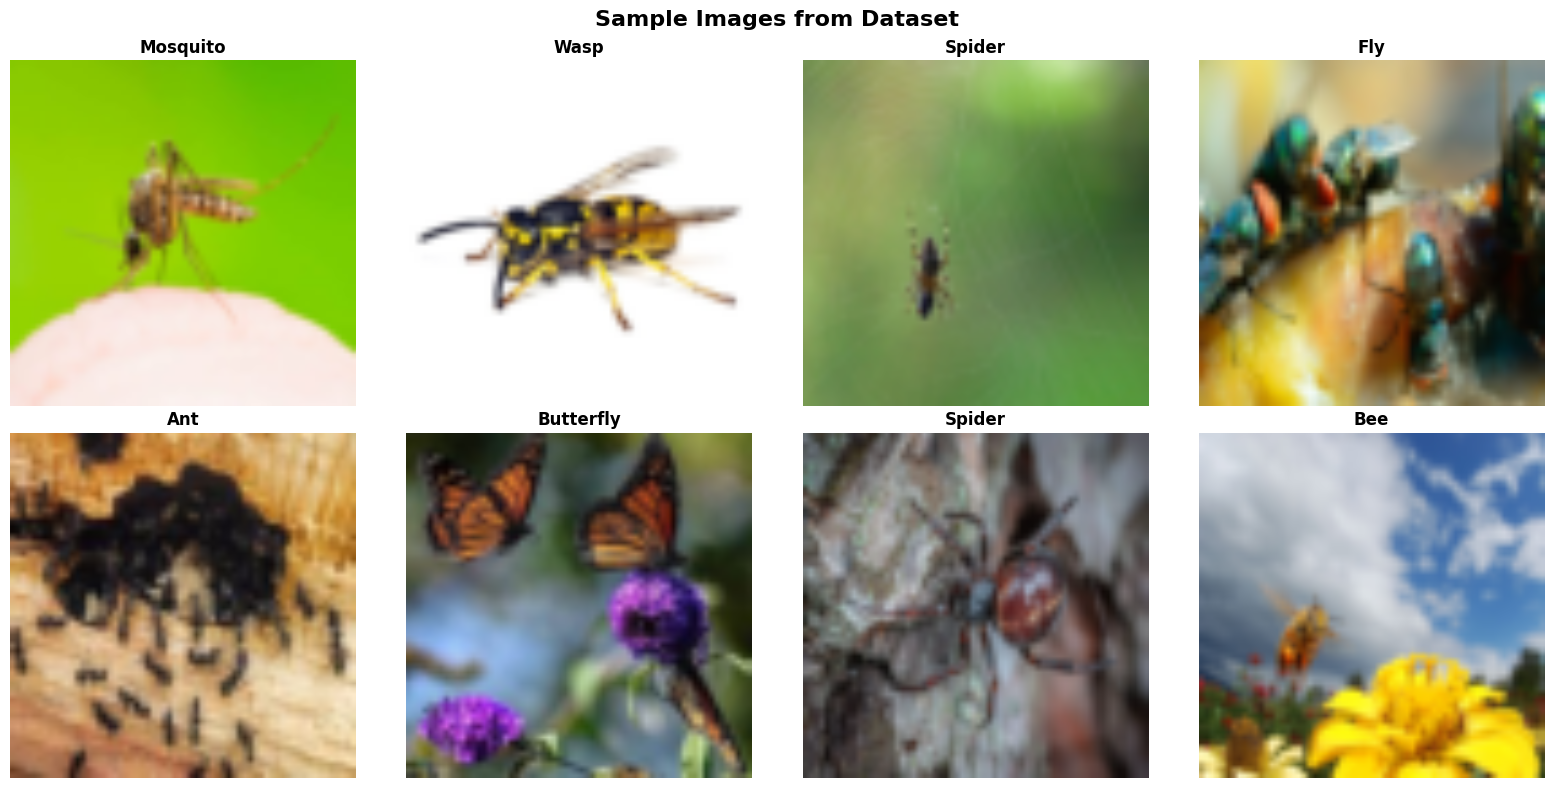

In [2]:
import warnings
# Suppress PIL warnings about palette images and EXIF data
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")
warnings.filterwarnings("ignore", category=UserWarning, module="PIL.TiffImagePlugin")

class InsectDataset(Dataset):
    """
    Custom dataset for loading insect images.
    Images are organized in subdirectories by insect type.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.insect_labels = []  # Track insect type for each image
        
        # Collect all image files from subdirectories
        for subdir in os.listdir(root_dir):
            subdir_path = os.path.join(root_dir, subdir)
            if os.path.isdir(subdir_path):
                for filename in os.listdir(subdir_path):
                    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(subdir_path, filename))
                        self.insect_labels.append(subdir)  # Store insect type
        
        print(f"Found {len(self.image_paths)} images")
        print(f"Insect categories: {sorted(set(self.insect_labels))}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        insect_label = self.insect_labels[idx]
        
        # Load image with proper error handling
        try:
            # Open image and convert to RGB (fixes palette/transparency warnings)
            with Image.open(img_path) as img:
                # Convert palette images to RGB
                if img.mode in ('P', 'RGBA', 'LA'):
                    img = img.convert('RGB')
                elif img.mode != 'RGB':
                    img = img.convert('RGB')
                image = img.copy()
        except Exception as e:
            # If image is corrupted, return a random other image
            return self.__getitem__(random.randint(0, len(self.image_paths) - 1))
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        return image, insect_label
    def get_label(self, idx):
        """Get insect label for a given index"""
        return self.insect_labels[idx]



# Define image transformations
# Normalize to [-1, 1] range as recommended for GANs
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # [-1, 1]
])

# Create dataset and dataloader
# pin_memory=True speeds up data transfer to GPU
def get_label(self, idx):
        """Get insect label for a given index"""
        return self.insect_labels[idx]

def collate_fn(batch):
    """Custom collate function to handle (image, label) tuples"""
    images = []
    labels = []
    for item in batch:
        if isinstance(item, tuple):
            images.append(item[0])
            labels.append(item[1])
        else:
            images.append(item)
            labels.append("Unknown")
    
    # Stack images into a tensor
    images = torch.stack(images)
    return images, labels

dataset = InsectDataset(root_dir='data', transform=transform)
dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True if torch.cuda.is_available() else False,
    collate_fn=collate_fn  # Custom collate to handle (image, label) tuples
)

# Visualize a sample batch
def show_samples(dataloader, num_samples=8, title="Sample Images from Dataset"):
    """Display a grid of sample images from the dataset with labels"""
    dataiter = iter(dataloader)
    batch = next(dataiter)
    
    # Handle both (images, labels) and just images
    if isinstance(batch, (tuple, list)) and len(batch) == 2:
        images, labels = batch
        # Ensure images is a tensor
        if not isinstance(images, torch.Tensor):
            # If it's a list of tensors, stack them
            images = torch.stack(images) if isinstance(images, list) else images
    else:
        images = batch
        labels = ['Unknown'] * len(images) if isinstance(images, torch.Tensor) else ['Unknown'] * len(batch)
    
    # Ensure images is a tensor
    if not isinstance(images, torch.Tensor):
        if isinstance(images, list):
            images = torch.stack(images)
        else:
            raise TypeError(f"Expected tensor or list, got {type(images)}")
    
    # Denormalize for display
    images = (images + 1) / 2.0  # Convert from [-1, 1] to [0, 1]
    images = torch.clamp(images, 0, 1)
    
    # Create figure with larger size for better visibility
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i in range(min(num_samples, len(images))):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, interpolation='bilinear')
        # Handle labels - could be list of strings or tensor
        if isinstance(labels, (list, tuple)):
            label = labels[i] if i < len(labels) else f"Image {i+1}"
        elif isinstance(labels, torch.Tensor):
            label = labels[i].item() if hasattr(labels[i], 'item') else str(labels[i])
        else:
            label = f"Image {i+1}"
        axes[i].set_title(f"{label}", fontsize=12, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Sample images from dataset:")
show_samples(dataloader)

## 3. Generator Network

The Generator uses **transposed convolutions** to upsample from a noise vector to a full image.

### Architecture:
- Input: Noise vector z of dimension 100
- Process: 
  1. Project to 4x4 feature maps with 512 channels
  2. Upsample through transposed convolutions: 4→8→16→32→64
  3. Each layer doubles spatial dimensions
- Output: 64×64×3 RGB image

### Key Components:
- **Transposed Convolution**: Upsamples by learning to "unfold" feature maps
- **Batch Normalization**: Stabilizes training by normalizing activations
- **ReLU**: Activation function (except last layer uses Tanh to output [-1, 1])

### Mathematical Operation:
For transposed convolution with stride s and padding p:
$$H_{out} = (H_{in} - 1) \times s - 2p + k$$

Where k is kernel size.


In [3]:
class Generator(nn.Module):
    """
    DCGAN Generator Network (Sharper Version)
    """
    def __init__(self, noise_dim=100, ngf=256):  # 🔺 increased capacity
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.ngf = ngf
        
        # Project noise to 4x4 feature maps
        self.fc = nn.Linear(noise_dim, 4 * 4 * ngf * 8)
        
        self.conv_layers = nn.Sequential(
            # 4x4 → 8x8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # 8x8 → 16x16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            # 16x16 → 32x32
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # 32x32 → 64x64
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            # ❌ NO BatchNorm here (important for sharpness)
            nn.Tanh()
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), self.ngf * 8, 4, 4)
        x = self.conv_layers(x)
        return x

# Initialize generator with increased capacity for better image quality
netG = Generator(noise_dim=NOISE_DIM, ngf=GEN_FILTERS).to(device)
print("Generator architecture:")
print(netG)

# Test generator with random noise
test_noise = torch.randn(1, NOISE_DIM, device=device)
test_output = netG(test_noise)
print(f"\nGenerator output shape: {test_output.shape}")
print(f"Expected shape: (1, 3, {IMAGE_SIZE}, {IMAGE_SIZE})")


Generator architecture:
Generator(
  (fc): Linear(in_features=100, out_features=32768, bias=True)
  (conv_layers): Sequential(
    (0): ConvTranspose2d(2048, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Generator output shape: torch.Size([1, 3, 64, 64])
Expected shape: (1, 3, 64, 64)


## 4. Discriminator Network

The Discriminator uses **strided convolutions** to downsample the image and classify it as real or fake.

### Architecture:
- Input: 64×64×3 RGB image
- Process: Downsample through convolutions: 64→32→16→8→4
- Output: Single probability (real/fake) via sigmoid

### Key Components:
- **Strided Convolution**: Downsamples by using stride > 1
- **LeakyReLU**: Allows small negative gradients (prevents dead neurons)
- **No BatchNorm in first layer**: Common practice in DCGAN
- **Sigmoid**: Outputs probability for BCE loss


In [4]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator (Texture-Sensitive)
    """
    def __init__(self, ndf=128):
        super(Discriminator, self).__init__()
        self.ndf = ndf
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )  # 64 → 32
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True)
        )  # 32 → 16
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True)
        )  # 16 → 8
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            # NO BatchNorm here
            nn.LeakyReLU(0.2, inplace=True)
        )  # 8 → 4
        
        # Final classifier
        self.final = nn.Sequential(
            nn.Conv2d(ndf * 8 + 1, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def minibatch_std(self, x):
        """
        Minibatch standard deviation layer
        Forces generator to produce high-frequency detail
        """
        std = torch.std(x, dim=0, unbiased=False).mean()
        std_map = std.expand(x.size(0), 1, x.size(2), x.size(3))
        return torch.cat([x, std_map], dim=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Texture sensitivity
        x = self.minibatch_std(x)
        
        x = self.final(x)
        return x.view(x.size(0), -1)


# Initialize discriminator with balanced capacity and reduced dropout
netD = Discriminator(ndf=DISC_FILTERS).to(device)  # Balanced: stronger but still regularized
print("Discriminator architecture:")
print(netD)

# Test discriminator with random image
test_image = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_score = netD(test_image)
print(f"\nDiscriminator output shape: {test_score.shape}")
print(f"Expected shape: (1, 1)")


Discriminator architecture:
Discriminator(
  (conv1): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv4): Sequential(
    (0): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (final): Sequential(
    (0): Conv2d(1025, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1)

## 5. Optimizers and Loss Functions

We use Adam optimizers for both networks with equal learning rates.

### Discriminator Loss:
$$L_D = -\mathbb{E}[\log D(x_{real})] - \mathbb{E}[\log(1 - D(x_{fake}))]$$

With label smoothing:
- Real labels: $1 - \alpha$ (e.g., 0.9)
- Fake labels: $\alpha$ (e.g., 0.1)

### Generator Loss:
$$L_G = -\mathbb{E}[\log D(x_{fake})]$$

The generator tries to maximize the discriminator's probability on fake images.


In [5]:
# Initialize optimizers
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

# IMPROVED: Add learning rate scheduling (cosine annealing)
# Gradually reduce learning rates for better convergence
print(f"Discriminator optimizer: Adam(lr={LEARNING_RATE}, betas=({BETA1}, {BETA2}))")
print(f"Generator optimizer: Adam(lr={LEARNING_RATE}, betas=({BETA1}, {BETA2}))")


Discriminator optimizer: Adam(lr=0.0002, betas=(0.5, 0.999))
Generator optimizer: Adam(lr=0.0002, betas=(0.5, 0.999))


## 6. Training Loop

The training process alternates between:
1. **Discriminator update**: Train discriminator to distinguish real from fake
2. **Generator update**: Train generator to fool the discriminator

### Training Steps:

**For each epoch:**
1. For each batch:
   - **Discriminator Training**:
     - Sample real images
     - Generate fake images from noise
     - Compute BCE loss with label smoothing
     - Update discriminator
   
   - **Generator Training**:
     - Generate fake images from noise
     - Compute generator loss (BCE)
     - Update generator

2. Save checkpoints periodically
3. Generate sample images to monitor progress

### Key Training Details:
- **1:1 Updates**: One discriminator update per generator update
- **BCE Loss**: Binary cross-entropy with label smoothing
- **Sigmoid Output**: Discriminator outputs probabilities
- **Device Management**: All tensors are explicitly placed on the same device (GPU) for efficient training


In [6]:
# Fixed noise for generating consistent samples during training
# Ensure it's on the correct device
fixed_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)

# Training statistics - IMPROVED: Enhanced monitoring
G_losses = []
D_losses = []
G_grad_norms = []  # Track generator gradient norms
D_grad_norms = []  # Track discriminator gradient norms
D_real_scores = []  # Track discriminator scores on real images
D_fake_scores = []  # Track discriminator scores on fake images

def save_checkpoint(epoch, netG, netD, optimizerG, optimizerD, losses):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'netG_state_dict': netG.state_dict(),
        'netD_state_dict': netD.state_dict(),
        'optimizerG_state_dict': optimizerG.state_dict(),
        'optimizerD_state_dict': optimizerD.state_dict(),
        'G_losses': losses[0],
        'D_losses': losses[1]
    }
    torch.save(checkpoint, f'checkpoints/checkpoint_epoch_{epoch}.pth')
    print(f"Checkpoint saved at epoch {epoch}")

def generate_samples(netG, noise, num_samples=16, save_path=None):
    """Generate and display sample images
    
    Args:
        netG: Generator network
        noise: Noise tensor of shape (N, noise_dim)
        num_samples: Number of samples to generate and display
        save_path: Optional path to save the figure
    """
    # Ensure noise is on the same device as the model
    noise = noise.to(next(netG.parameters()).device)
    
    # Limit num_samples to available noise
    num_samples = min(num_samples, noise.size(0))
    
    netG.eval()
    with torch.no_grad():
        fake_images = netG(noise[:num_samples])
        fake_images = (fake_images + 1) / 2.0  # Denormalize to [0, 1]
        fake_images = torch.clamp(fake_images, 0, 1)
    
    netG.train()
    
    # FIXED: Dynamically calculate grid size based on num_samples
    # Calculate grid dimensions (try to make it roughly square)
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    rows = grid_size
    cols = grid_size
    
    # Adjust if we have fewer samples than grid_size^2
    if num_samples < grid_size * grid_size:
        # Try to make it more rectangular if needed
        if num_samples <= grid_size * (grid_size - 1):
            cols = grid_size - 1
    
    # Create grid of images with appropriate size
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    
    # Handle both single subplot and multiple subplots
    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Display images
    for i in range(num_samples):
        # Move to CPU for visualization
        img = fake_images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, interpolation='bilinear')
        axes[i].set_title(f"Generated {i+1}", fontsize=10, fontweight='bold')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f"Generated Insect Images ({num_samples} samples)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Training utilities initialized")
print(f"Fixed noise shape for sampling: {fixed_noise.shape}")
print(f"Fixed noise device: {fixed_noise.device}")


Training utilities initialized
Fixed noise shape for sampling: torch.Size([64, 100])
Fixed noise device: cuda:0


In [7]:
# Main training loop
print("Starting training...")
print(f"Total epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Device: {device}")
print("-" * 50)

# Loss function
criterion = nn.BCELoss()

# Fixed noise for generating consistent samples during training
fixed_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)

# Training statistics
G_losses = []
D_losses = []

for epoch in range(NUM_EPOCHS):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    
    # Progress bar
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch_idx, batch_data in enumerate(pbar):
        real_images, _ = batch_data
        batch_size = real_images.size(0)
        real_images = real_images.to(device, non_blocking=True)
        
        # ============================================
        # Train Discriminator
        # ============================================
        netD.zero_grad()
        
        # Real images
        real_labels = torch.full((batch_size,), 1.0 - LABEL_SMOOTHING, device=device)  # Label smoothing: 0.9
        real_output = netD(real_images).view(-1)
        d_loss_real = criterion(real_output, real_labels)
        
        # Fake images
        noise = torch.randn(batch_size, NOISE_DIM, device=device, dtype=torch.float32)
        fake_images = netG(noise)
        fake_labels = torch.full((batch_size,), LABEL_SMOOTHING, device=device)  # Label smoothing: 0.1
        fake_output = netD(fake_images.detach()).view(-1)
        d_loss_fake = criterion(fake_output, fake_labels)
        
        # Total discriminator loss
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizerD.step()
        
        epoch_D_loss += d_loss.item()
        
        # ============================================
        # Train Generator
        # ============================================
        netG.zero_grad()
        
        # Generate fake images and try to fool discriminator
        noise = torch.randn(batch_size, NOISE_DIM, device=device, dtype=torch.float32)
        fake_images = netG(noise)
        real_labels = torch.full((batch_size,), 1.0, device=device)  # Generator wants D to output 1.0
        fake_output = netD(fake_images).view(-1)
        g_loss = criterion(fake_output, real_labels)
        
        g_loss.backward()
        optimizerG.step()
        
        epoch_G_loss += g_loss.item()
        
        # Update progress bar
        pbar.set_postfix({
            'D_loss': f'{d_loss.item():.4f}',
            'G_loss': f'{g_loss.item():.4f}'
        })
    
    # Average losses for the epoch
    avg_D_loss = epoch_D_loss / len(dataloader)
    avg_G_loss = epoch_G_loss / len(dataloader)
    
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)
    
    # Print epoch statistics
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Discriminator Loss: {avg_D_loss:.4f}")
    print(f"  Generator Loss: {avg_G_loss:.4f}")
    
    # Save checkpoint
    if (epoch + 1) % SAVE_INTERVAL == 0:
        torch.save({
            'epoch': epoch + 1,
            'generator_state_dict': netG.state_dict(),
            'discriminator_state_dict': netD.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerD_state_dict': optimizerD.state_dict(),
            'G_losses': G_losses,
            'D_losses': D_losses,
        }, f'checkpoints/checkpoint_epoch_{epoch+1}.pth')
        print(f"  Checkpoint saved: checkpoints/checkpoint_epoch_{epoch+1}.pth")
    
    # Generate sample images
    with torch.no_grad():
        fake_samples = netG(fixed_noise).detach().cpu()
        fake_samples = (fake_samples + 1) / 2.0  # Denormalize from [-1, 1] to [0, 1]
        fake_samples = torch.clamp(fake_samples, 0, 1)
        
        # Save sample images
        if (epoch + 1) % SAVE_INTERVAL == 0:
            fig, axes = plt.subplots(8, 8, figsize=(16, 16))
            for i in range(64):
                row, col = i // 8, i % 8
                img = fake_samples[i].permute(1, 2, 0).numpy()
                axes[row, col].imshow(img)
                axes[row, col].axis('off')
            plt.tight_layout()
            plt.savefig(f'samples/epoch_{epoch+1}.png')
            plt.close()
            print(f"  Sample images saved: samples/epoch_{epoch+1}.png")

print("\nTraining completed!")


Starting training...
Total epochs: 100
Batch size: 64
Learning rate: 0.0002
Label smoothing: 0.1
Device: cuda
--------------------------------------------------


Epoch 1/100: 100%|██████████| 128/128 [00:21<00:00,  5.85it/s, D_loss=0.9921, G_loss=1.2070]



Epoch [1/100]
  Discriminator Loss: 0.7934
  Generator Loss: 3.1947


Epoch 2/100: 100%|██████████| 128/128 [00:21<00:00,  5.85it/s, D_loss=3.1218, G_loss=0.9736]



Epoch [2/100]
  Discriminator Loss: 0.9426
  Generator Loss: 2.7091


...


Epoch [98/100]
  Discriminator Loss: 0.7982
  Generator Loss: 2.3531


Epoch 99/100: 100%|██████████| 128/128 [00:21<00:00,  5.89it/s, D_loss=0.7437, G_loss=2.9131]



Epoch [99/100]
  Discriminator Loss: 0.7797
  Generator Loss: 2.3048


Epoch 100/100: 100%|██████████| 128/128 [00:22<00:00,  5.72it/s, D_loss=0.7970, G_loss=2.6865]



Epoch [100/100]
  Discriminator Loss: 0.7712
  Generator Loss: 2.3755
  Checkpoint saved: checkpoints/checkpoint_epoch_100.pth
  Sample images saved: samples/epoch_100.png

Training completed!


## 7. Training Diagnostic

Run this cell after training to diagnose why losses might be increasing and check training health.

In [8]:
# Quick diagnostic to understand loss behavior
if len(G_losses) > 0 and len(D_losses) > 0:
    print("=" * 60)
    print("TRAINING DIAGNOSTIC - Understanding Loss Behavior")
    print("=" * 60)
    
    # Current state
    print(f"\n📊 CURRENT STATE (Epoch {len(G_losses)}):")
    print(f"   Generator Loss: {G_losses[-1]:.4f}")
    print(f"   Discriminator Loss: {D_losses[-1]:.4f}")
    
    
    if len(D_real_scores) > 0 and len(D_fake_scores) > 0:
        gap = D_real_scores[-1] - D_fake_scores[-1]
        print(f"   D(real): {D_real_scores[-1]:.4f}, D(fake): {D_fake_scores[-1]:.4f}")
        print(f"   Score Gap: {gap:.4f} {'⚠️ LARGE' if gap > 10.0 else '✅ OK'}")
    
    # Trend analysis
    if len(G_losses) >= 10:
        print(f"\n📈 TRENDS (Last 10 epochs):")
        early_G = sum(G_losses[-10:-5]) / 5
        late_G = sum(G_losses[-5:]) / 5
        G_change = late_G - early_G
        print(f"   Generator Loss: {early_G:.4f} → {late_G:.4f} (change: {G_change:+.4f})")
        if G_change > 2.0:
            print("   ❌ Generator loss INCREASING - Generator is failing!")
            print("   → Discriminator too strong - reduce N_CRITIC or D learning rate")
        elif G_change < -2.0:
            print("   ✅ Generator loss DECREASING - Generator is improving!")
        else:
            print("   ⚠️  Generator loss relatively stable")
        
        early_D = sum(D_losses[-10:-5]) / 5
        late_D = sum(D_losses[-5:]) / 5
        D_change = late_D - early_D
        print(f"   Discriminator Loss: {early_D:.4f} → {late_D:.4f} (change: {D_change:+.4f})")
        if D_change < -10.0:
            print("   ❌ Discriminator loss becoming VERY negative - Discriminator too strong!")
            print("   → Reduce discriminator learning rate or N_CRITIC")
        elif abs(D_change) < 5.0:
            print("   ✅ Discriminator loss relatively stable")
    
    # Score gap trend
    if len(D_real_scores) >= 10 and len(D_fake_scores) >= 10:
        early_gap = sum([D_real_scores[i] - D_fake_scores[i] for i in range(-10, -5)]) / 5
        late_gap = sum([D_real_scores[i] - D_fake_scores[i] for i in range(-5, 0)]) / 5
        gap_change = late_gap - early_gap
        print(f"\n   Score Gap: {early_gap:.4f} → {late_gap:.4f} (change: {gap_change:+.4f})")
        if gap_change < -1.0:
            print("   ✅ Gap DECREASING - Training converging!")
        elif gap_change > 2.0:
            print("   ❌ Gap INCREASING - Discriminator getting stronger!")
        else:
            print("   ⚠️  Gap relatively stable")
    
    # Overall assessment
    print(f"\n🎯 ASSESSMENT:")
    issues = []
    if len(G_losses) >= 10 and sum(G_losses[-5:])/5 > sum(G_losses[-10:-5])/5 + 2.0:
        issues.append("Generator loss increasing")
    if len(D_losses) > 0 and D_losses[-1] < -50.0:
        issues.append("Discriminator loss extremely negative")
    if len(D_real_scores) > 0 and len(D_fake_scores) > 0:
        if D_real_scores[-1] - D_fake_scores[-1] > 10.0:
            issues.append("Large score gap (discriminator too strong)")
    
    if not issues:
        print("   ✅ Training appears HEALTHY!")
        print("   → Check generated images for visual quality")
    else:
        print("   ⚠️  Issues detected:")
        for issue in issues:
            print(f"      - {issue}")
        print("\n   💡 RECOMMENDATIONS:")
        if "Generator loss increasing" in str(issues):
            print("      → Reduce N_CRITIC (try 1 or 2)")
            print("      → Reduce discriminator learning rate")
        if "Discriminator loss extremely negative" in str(issues) or "Large score gap" in str(issues):
            print("      → Reduce N_CRITIC to 1 or 2")
            print("      → Reduce discriminator learning rate further")
            print("      → Increase dropout rate")
            print("      → Reduce learning rates")
    
    print("\n" + "=" * 60)
    print("💡 REMEMBER: In WGAN, negative losses are often GOOD!")
    print("   - Negative G_loss = Generator fooling discriminator ✅")
    print("   - Negative D_loss = Discriminator distinguishing real/fake ✅")
    print("=" * 60)
else:
    print("⚠️  No training data available. Run training first!")

TRAINING DIAGNOSTIC - Understanding Loss Behavior

📊 CURRENT STATE (Epoch 100):
   Generator Loss: 2.3755
   Discriminator Loss: 0.7712

📈 TRENDS (Last 10 epochs):
   Generator Loss: 2.2516 → 2.3475 (change: +0.0959)
   ⚠️  Generator loss relatively stable
   Discriminator Loss: 0.8188 → 0.7811 (change: -0.0376)
   ✅ Discriminator loss relatively stable

🎯 ASSESSMENT:
   ✅ Training appears HEALTHY!
   → Check generated images for visual quality

💡 REMEMBER: In WGAN, negative losses are often GOOD!
   - Negative G_loss = Generator fooling discriminator ✅
   - Negative D_loss = Discriminator distinguishing real/fake ✅


## 8. Training Loss Visualization

Plot the training losses to monitor convergence. In a well-trained GAN:
- Discriminator and Generator losses should stabilize
- They don't necessarily converge to zero (unlike traditional losses)
- The key is that generated images look realistic


## 9. Check Image Quality and Diversity

Check if generated images are diverse or if mode collapse is occurring (all images look the same/blurry).

Checking image diversity and quality...
IMAGE QUALITY & DIVERSITY CHECK

📊 Metrics:
   Pixel Variance: 0.0467
   Mean Pixel Value: 0.4554 (should be ~0.5)
   Image Diversity (std of means): 0.1232

🎯 Assessment:
   ⚠️  LOW diversity - Some mode collapse
   → Images might be too similar
   ✅ Mean pixel value normal
   ✅ Good brightness diversity

💡 If images are blurry:
   - Check discriminator score gap (should be 2-5, not < 0.5)
   - Discriminator might be too weak (reduce dropout)
   - Generator might need more capacity (increase ngf)
   - May need more training epochs

Visual inspection of generated samples:


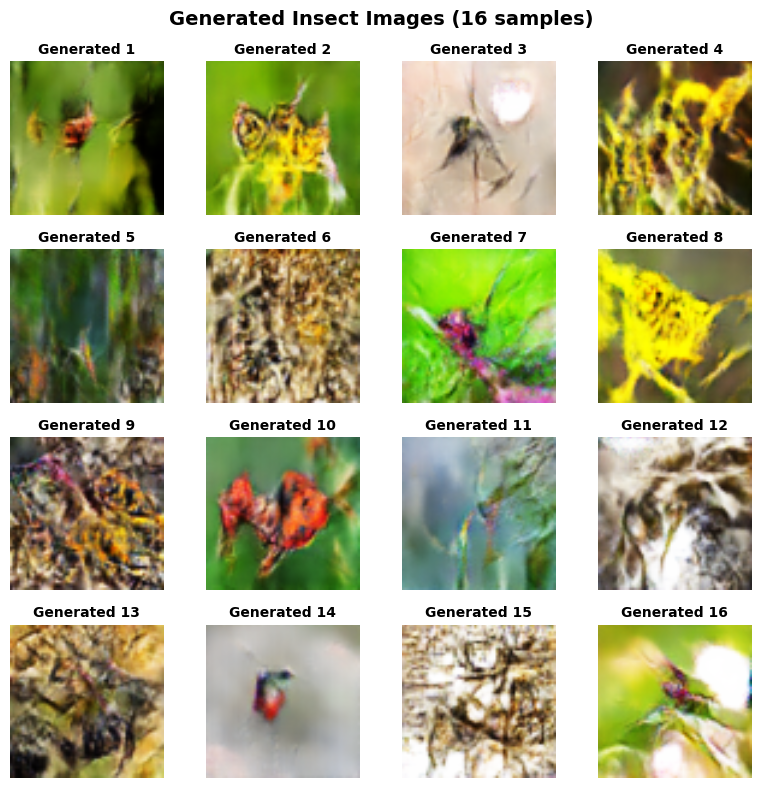

In [9]:
# Check image diversity and quality
def check_image_diversity(netG, num_samples=16, seed=42):
    """Check if generated images are diverse (not mode collapse)"""
    # Set seed for reproducibility
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    # Generate samples
    noise = torch.randn(num_samples, NOISE_DIM, device=device, dtype=torch.float32)
    
    netG.eval()
    with torch.no_grad():
        images = netG(noise)
        images = (images + 1) / 2.0  # Denormalize
        images = torch.clamp(images, 0, 1)
    
    netG.train()
    
    # Calculate diversity metrics
    # 1. Pixel-wise variance across samples (higher = more diverse)
    pixel_variance = torch.var(images, dim=0).mean().item()
    
    # 2. Mean pixel value (should be around 0.5 if balanced)
    mean_pixel = images.mean().item()
    
    # 3. Standard deviation of mean values per image (higher = more diverse)
    per_image_means = images.view(num_samples, -1).mean(dim=1)
    image_diversity = per_image_means.std().item()
    
    print("=" * 60)
    print("IMAGE QUALITY & DIVERSITY CHECK")
    print("=" * 60)
    print(f"\n📊 Metrics:")
    print(f"   Pixel Variance: {pixel_variance:.4f}")
    print(f"   Mean Pixel Value: {mean_pixel:.4f} (should be ~0.5)")
    print(f"   Image Diversity (std of means): {image_diversity:.4f}")
    
    # Assessment
    print(f"\n🎯 Assessment:")
    if pixel_variance < 0.01:
        print("   ❌ VERY LOW diversity - Mode collapse likely!")
        print("   → Images are too similar (all blurry/same)")
    elif pixel_variance < 0.05:
        print("   ⚠️  LOW diversity - Some mode collapse")
        print("   → Images might be too similar")
    else:
        print("   ✅ GOOD diversity - Images are varied")
    
    if mean_pixel < 0.3 or mean_pixel > 0.7:
        print("   ⚠️  Mean pixel value unusual - might indicate training issues")
    else:
        print("   ✅ Mean pixel value normal")
    
    if image_diversity < 0.01:
        print("   ❌ Images have very similar brightness - mode collapse!")
    elif image_diversity < 0.05:
        print("   ⚠️  Low brightness diversity")
    else:
        print("   ✅ Good brightness diversity")
    
    print("\n💡 If images are blurry:")
    print("   - Check discriminator score gap (should be 2-5, not < 0.5)")
    print("   - Discriminator might be too weak (reduce dropout)")
    print("   - Generator might need more capacity (increase ngf)")
    print("   - May need more training epochs")
    print("=" * 60)
    
    return images, pixel_variance, image_diversity

# Run diversity check
print("Checking image diversity and quality...")
diversity_images, pixel_var, img_div = check_image_diversity(netG, num_samples=16)

# Display a few samples for visual inspection
print("\nVisual inspection of generated samples:")
generate_samples(netG, torch.randn(16, NOISE_DIM, device=device), num_samples=16)

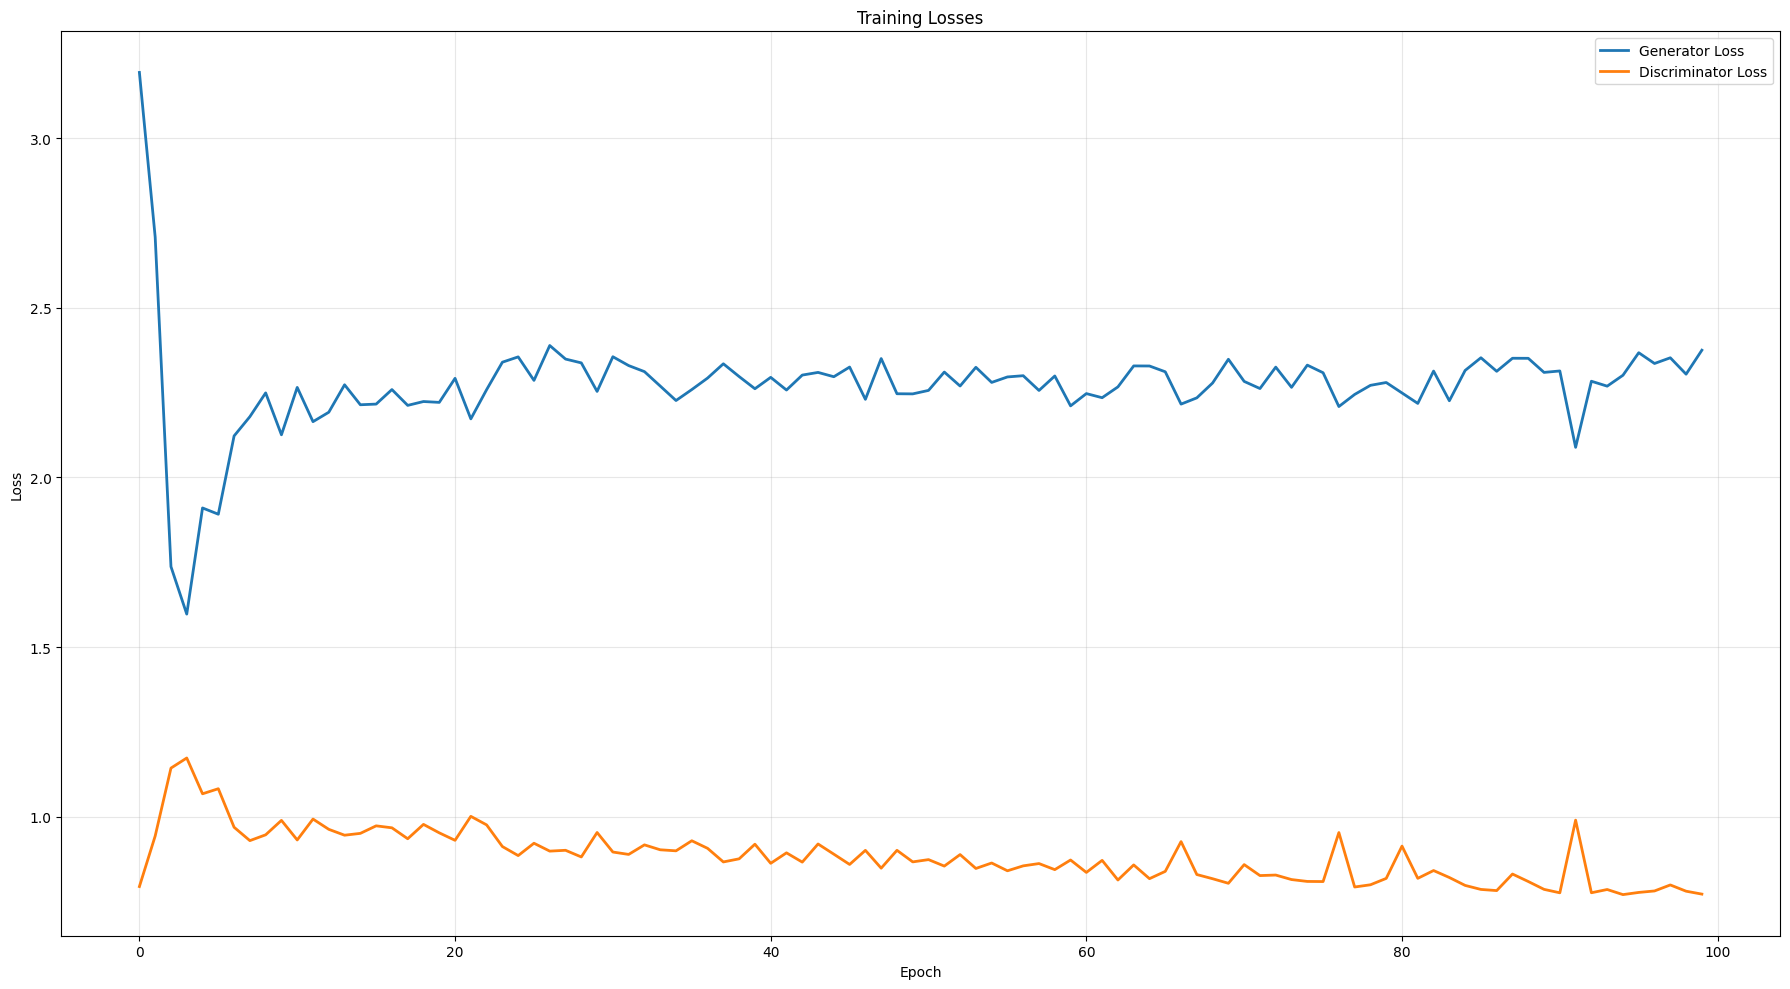

In [10]:
# IMPROVED: Enhanced training visualization with all metrics
fig= plt.figure(figsize=(18, 10))

# Losses
plt.plot(G_losses, label='Generator Loss', linewidth=2)
plt.plot(D_losses, label='Discriminator Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_losses.png', dpi=150, bbox_inches='tight')
plt.show()



## 9. Generate Final Samples

Generate a large batch of samples to evaluate the trained model's performance.


Generating final samples...


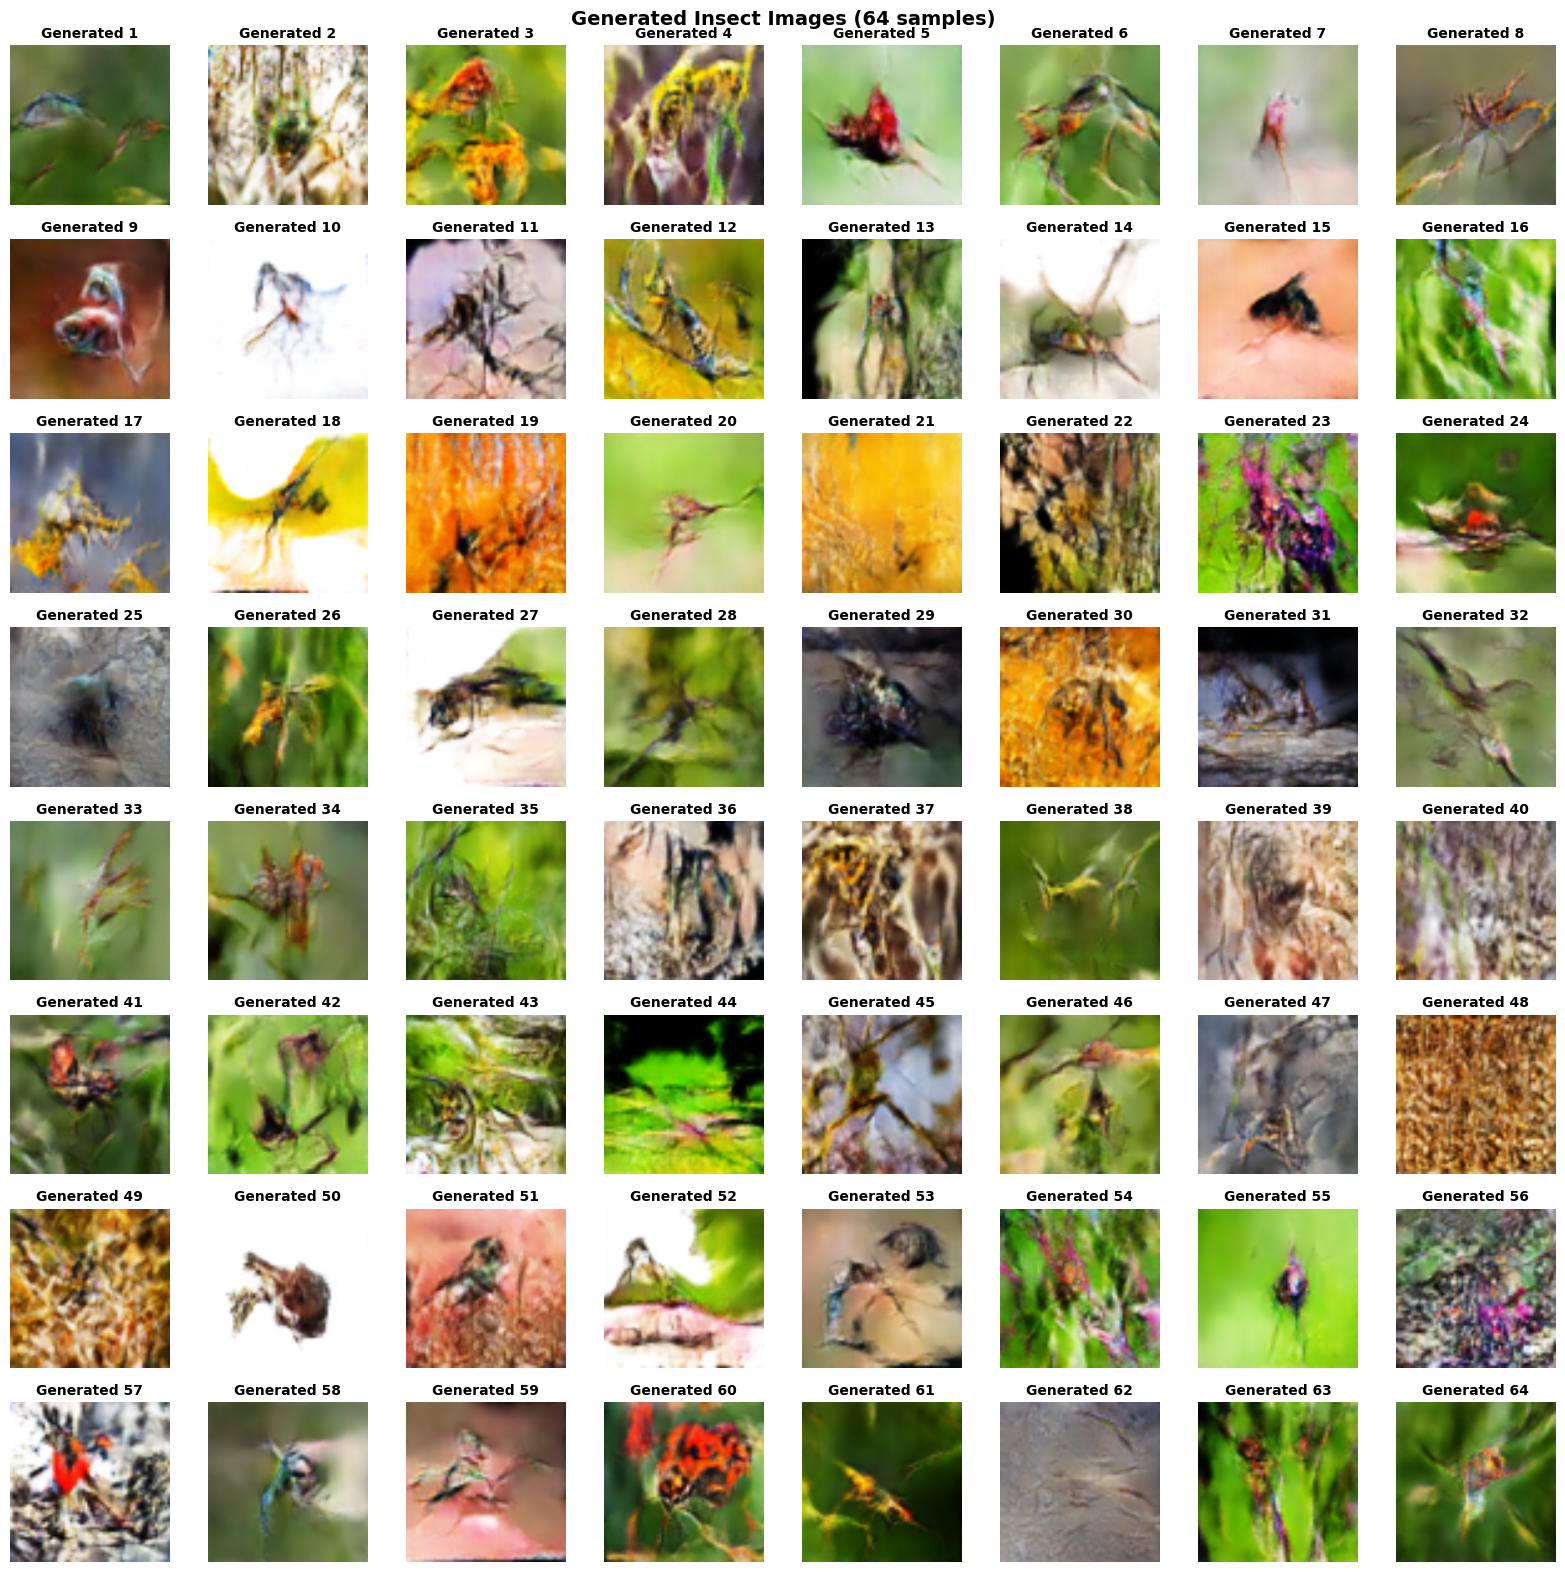

In [11]:
# Generate final samples
print("Generating final samples...")
final_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)
generate_samples(netG, final_noise, num_samples=64, save_path='samples/final_samples.png')


## 10. Model Architecture Summary

### Generator Architecture Details:

**Input Layer:**
- Fully connected: 100 → 8192 (4×4×512)
- Reshape to: (batch, 512, 4, 4)

**Transposed Convolutional Layers:**
1. ConvTranspose2d(512, 256, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 256, 8, 8)
2. ConvTranspose2d(256, 128, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 128, 16, 16)
3. ConvTranspose2d(128, 64, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 64, 32, 32)
4. ConvTranspose2d(64, 3, kernel=4, stride=2, padding=1) + Tanh
   - Output: (batch, 3, 64, 64)

### Discriminator Architecture Details:

**Convolutional Layers:**
1. Conv2d(3, 64, kernel=4, stride=2, padding=1) + LeakyReLU(0.2)
   - Output: (batch, 64, 32, 32)
2. Conv2d(64, 128, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 128, 16, 16)
3. Conv2d(128, 256, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 256, 8, 8)
4. Conv2d(256, 512, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 512, 4, 4)
5. Conv2d(512, 1, kernel=4, stride=1, padding=0)
   - Output: (batch, 1, 1, 1) → flattened to (batch, 1)

## Key Equations Recap

### Transposed Convolution Output Size:
$$H_{out} = (H_{in} - 1) \times s - 2p + k$$

### Regular Convolution Output Size:
$$H_{out} = \lfloor \frac{H_{in} + 2p - k}{s} \rfloor + 1$$

### WGAN-GP Loss:
$$L_D = \mathbb{E}[D(G(z))] - \mathbb{E}[D(x)] + \lambda \mathbb{E}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$
$$L_G = -\mathbb{E}[D(G(z))]$$

Where:
- $x$: real samples
- $G(z)$: generated samples
- $\hat{x} = \epsilon x + (1-\epsilon)G(z)$: interpolated samples
- $\lambda = 10$: gradient penalty coefficient


## 11. Loading Saved Models

Use this cell to load a previously saved checkpoint and continue training or generate samples.


In [12]:
def load_checkpoint(checkpoint_path, netG, netD, optimizerG, optimizerD):
    """Load model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    netG.load_state_dict(checkpoint['netG_state_dict'])
    netD.load_state_dict(checkpoint['netD_state_dict'])
    optimizerG.load_state_dict(checkpoint['optimizerG_state_dict'])
    optimizerD.load_state_dict(checkpoint['optimizerD_state_dict'])
    
    epoch = checkpoint['epoch']
    G_losses = checkpoint['G_losses']
    D_losses = checkpoint['D_losses']
    
    print(f"Checkpoint loaded from epoch {epoch}")
    return epoch, G_losses, D_losses

# Example usage (uncomment to load a checkpoint):
# epoch, G_losses, D_losses = load_checkpoint(
#     'checkpoints/checkpoint_epoch_50.pth',
#     netG, netD, optimizerG, optimizerD
# )


## 12. Interactive Sample Generation

Generate custom samples by providing your own noise vectors or random seeds.


Generating samples with seed=42:


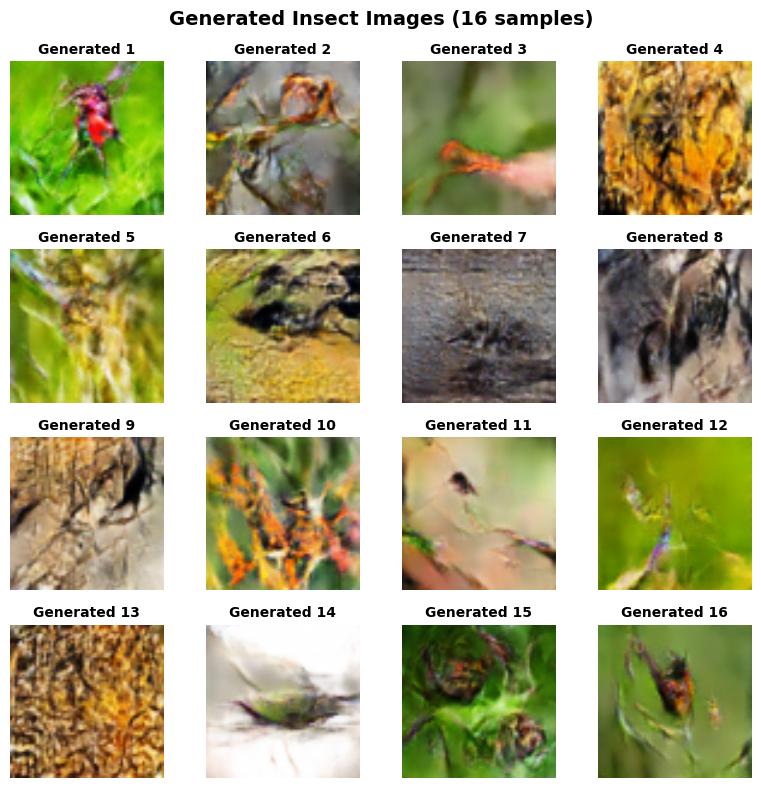


Generating random samples:


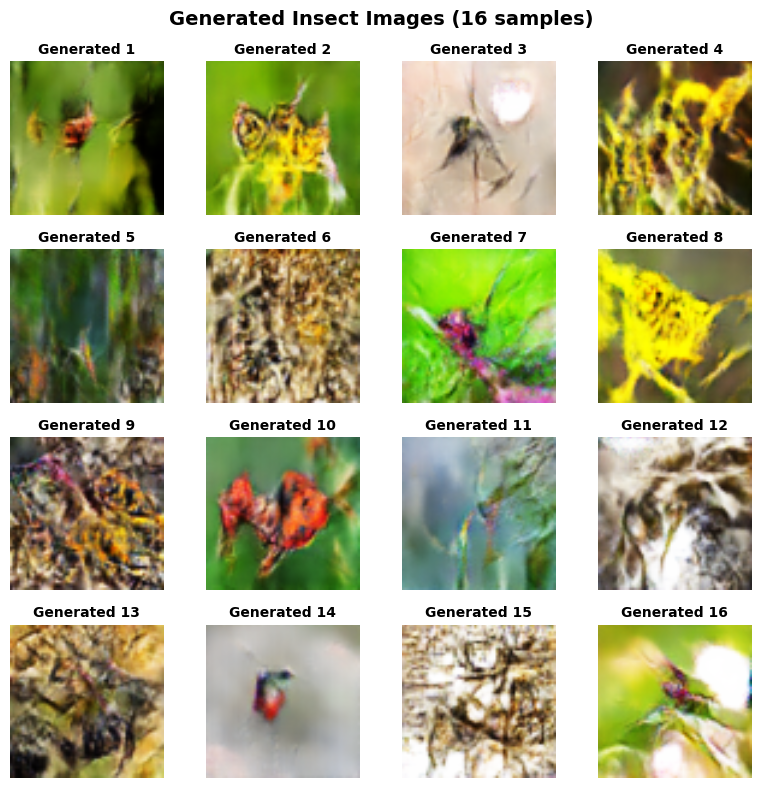

In [13]:
def generate_custom_samples(netG, num_samples=16, seed=None):
    """Generate samples with optional seed for reproducibility"""
    # Get device from model
    model_device = next(netG.parameters()).device
    
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
    
    # Ensure noise is on the same device as the model
    noise = torch.randn(num_samples, NOISE_DIM, device=model_device, dtype=torch.float32)
    generate_samples(netG, noise, num_samples=num_samples)

# Generate samples with a specific seed
print("Generating samples with seed=42:")
generate_custom_samples(netG, num_samples=16, seed=42)

# Generate random samples
print("\nGenerating random samples:")
generate_custom_samples(netG, num_samples=16, seed=None)
